In [53]:
import pandas as pd
movies = pd.read_csv(r'C:\Users\pc\Downloads\MoviesTopRated.csv\MoviesTopRated.csv')
print(movies.head())

   Unnamed: 0     id        genre_ids                        title  \
0           0    238         [18, 80]                The Godfather   
1           1    278         [18, 80]     The Shawshank Redemption   
2           2    240         [18, 80]        The Godfather Part II   
3           3    424  [18, 36, 10752]             Schindler's List   
4           4  19404  [35, 18, 10749]  Dilwale Dulhania Le Jayenge   

                                            overview  popularity release_date  \
0  Spanning the years 1945 to 1955, a chronicle o...     119.438   1972-03-14   
1  Framed in the 1940s for the double murder of h...      90.415   1994-09-23   
2  In the continuing saga of the Corleone crime f...      70.637   1974-12-20   
3  The true story of how businessman Oskar Schind...      48.096   1993-12-15   
4  Raj is a rich, carefree, happy-go-lucky second...      26.588   1995-10-20   

   vote_average  vote_count  
0           8.7       18448  
1           8.7       24376  
2 

In [54]:
movies.columns

Index(['Unnamed: 0', 'id', 'genre_ids', 'title', 'overview', 'popularity',
       'release_date', 'vote_average', 'vote_count'],
      dtype='object')

In [55]:
movies.isna().sum()

Unnamed: 0      0
id              0
genre_ids       0
title           0
overview        2
popularity      0
release_date    0
vote_average    0
vote_count      0
dtype: int64

In [56]:
movies.dropna(inplace = True)

In [57]:
movies.isna().sum()

Unnamed: 0      0
id              0
genre_ids       0
title           0
overview        0
popularity      0
release_date    0
vote_average    0
vote_count      0
dtype: int64

In [58]:
movies.duplicated().sum()

np.int64(0)

In [59]:
movies.head()

,Unnamed: 0,id,genre_ids,title,overview,popularity,release_date,vote_average,vote_count
0,0,238,"[18, 80]",The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",119.438,1972-03-14,8.7,18448
1,1,278,"[18, 80]",The Shawshank Redemption,Framed in the 1940s for the double murder of h...,90.415,1994-09-23,8.7,24376
2,2,240,"[18, 80]",The Godfather Part II,In the continuing saga of the Corleone crime f...,70.637,1974-12-20,8.6,11144
3,3,424,"[18, 36, 10752]",Schindler's List,The true story of how businessman Oskar Schind...,48.096,1993-12-15,8.6,14421
4,4,19404,"[35, 18, 10749]",Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...",26.588,1995-10-20,8.6,4225


In [60]:
movies.info

<bound method DataFrame.info of       Unnamed: 0      id        genre_ids                           title  \
0              0     238         [18, 80]                   The Godfather   
1              1     278         [18, 80]        The Shawshank Redemption   
2              2     240         [18, 80]           The Godfather Part II   
3              3     424  [18, 36, 10752]                Schindler's List   
4              4   19404  [35, 18, 10749]     Dilwale Dulhania Le Jayenge   
...          ...     ...              ...                             ...   
9995        9995  604563     [35, 12, 28]  OSS 117: From Africa with Love   
9996        9996  193687        [878, 18]                 Z for Zachariah   
9997        9997   14423         [35, 28]                    First Sunday   
9998        9998   10154  [35, 80, 10749]                Mickey Blue Eyes   
9999        9999  440762             [35]       Jay and Silent Bob Reboot   

                                           

In [61]:
movies.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,9998.000000,9.998000e+03,9998.000000,9998.000000,9998.000000
mean,4998.829466,1.847541e+05,21.549165,6.771884,1673.954691
std,2886.748710,2.415783e+05,76.301605,0.637031,2890.338087
min,0.000000,2.000000e+00,0.600000,5.700000,200.000000
25%,2499.250000,1.033925e+04,9.120000,6.300000,322.000000
50%,4998.500000,3.520150e+04,12.441500,6.700000,611.000000
75%,7498.750000,3.475632e+05,19.557500,7.200000,1588.750000
max,9999.000000,1.140066e+06,4696.546000,8.700000,34262.000000


In [62]:
movies.shape

(9998, 9)

In [63]:
movies.drop(columns='Unnamed: 0' , inplace=True)

In [64]:
movies.reset_index(drop=True, inplace=True)

In [27]:
genre_map = {
    28: "Action",
    12: "Adventure",
    16: "Animation",
    35: "Comedy",
    80: "Crime",
    99: "Documentary",
    18: "Drama",
    10751: "Family",
    14: "Fantasy",
    36: "History",
    27: "Horror",
    10402: "Music",
    9648: "Mystery",
    10749: "Romance",
    878: "ScienceFiction",
    10770: "TVMovie",
    53: "Thriller",
    10752: "War",
    37: "Western"
}

In [28]:
import ast

In [29]:
def convert_genres(obj):
    genres = []

    try:
        ids = ast.literal_eval(obj)

        for i in ids:
            if i in genre_map:
                genres.apped(genre_map[i])

    except:
        pass

    return ' '.join(genres)

In [65]:
movies['genres'] = movies['genre_ids'].apply(convert_genres)

In [66]:
movies[['genre_ids','genres']].head()

,genre_ids,genres
0,"[18, 80]",
1,"[18, 80]",
2,"[18, 80]",
3,"[18, 36, 10752]",
4,"[35, 18, 10749]",


In [67]:
movies['overview'] = movies['overview'].astype(str)

In [68]:
movies['tags'] = movies['overview'] + movies['genres']

In [69]:
movies['tags']= movies['tags'].apply(lambda x: x.lower())

In [70]:
movies[['title','tags']].head()

,title,tags
0,The Godfather,"spanning the years 1945 to 1955, a chronicle o..."
1,The Shawshank Redemption,framed in the 1940s for the double murder of h...
2,The Godfather Part II,in the continuing saga of the corleone crime f...
3,Schindler's List,the true story of how businessman oskar schind...
4,Dilwale Dulhania Le Jayenge,"raj is a rich, carefree, happy-go-lucky second..."


In [71]:
from sklearn.feature_extraction.text import CountVectorizer

In [72]:
cv = CountVectorizer(
    max_features=5000,
    stop_words = 'english'
)

In [73]:
vectors = cv.fit_transform(movies['tags']).toarray()

In [74]:
vectors.shape

(9998, 5000)

In [75]:
from sklearn.metrics.pairwise import cosine_similarity

In [76]:
similarity = cosine_similarity(vectors)

In [77]:
similarity.shape

(9998, 9998)

In [79]:
def recommend(movie):

    movie = movie.lower()

    
    movie_index = movies[
        movies['title'].str.lower() == movie
    ].index[0]

    
    distances = similarity[movie_index]

    
    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print(f"\nRecommended movies for {movie.title()}:\n")

    for i in movies_list:
        print(movies.iloc[i[0]].title)

In [80]:
recommend('Avatar')


Recommended movies for Avatar:

Beowulf
Europa Report
Tears of the Sun
The Assassin
Prospect


In [81]:
movies = movies[movies['vote_count'] >100]

In [82]:
movies['release_year'] = pd.to_datetime(
    movies['release_date']
).dt.year

In [84]:
movies.sort_values(
    'popularity',
    ascending = False
)[['title', 'popularity']].head(10)

,title,popularity
776,Elemental,4696.546
16,Spider-Man: Across the Spider-Verse,2517.658
3725,Heart of Stone,1851.905
3302,No Hard Feelings,1812.181
1686,Barbie,1748.951
1463,Transformers: Rise of the Beasts,1691.784
3620,Meg 2: The Trench,1424.145
3754,The Flash,1377.709
3997,Insidious: The Red Door,1147.176
2176,Fast X,1058.630


In [86]:
movies.sort_values(
    'vote_average',
    ascending=False
)[['title', 'vote_average']].head(10)

,title,vote_average
0,The Godfather,8.7
1,The Shawshank Redemption,8.7
2,The Godfather Part II,8.6
3,Schindler's List,8.6
4,Dilwale Dulhania Le Jayenge,8.6
13,The Lord of the Rings: The Return of the King,8.5
22,Grave of the Fireflies,8.5
21,Seven Samurai,8.5
20,Gabriel's Inferno,8.5
17,Cinema Paradiso,8.5


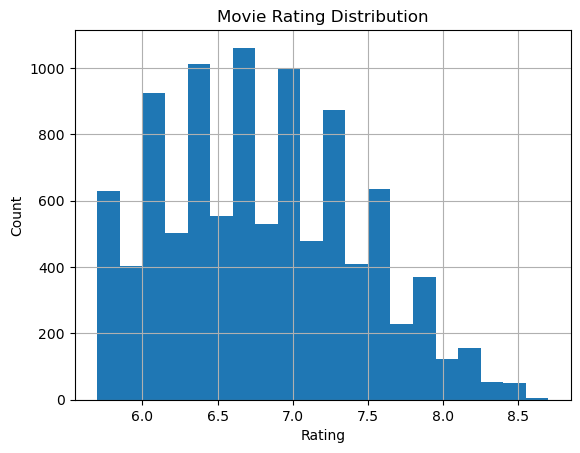

In [88]:
import matplotlib.pyplot as plt

movies['vote_average'].hist(bins=20)

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Movie Rating Distribution')

plt.show()

In [89]:
movies.to_csv('processed_movies.csv', index=False)